In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

In [ ]:
# Cargar el dataset reducido exportado para Power BI
dashboard_df = pd.read_csv('../dashboard/dashboard_data.csv')
# Usa las columnas más relevantes del análisis
features = ['V14', 'V12', 'V10', 'V17', 'Amount']
X = dashboard_df[features]
y = dashboard_df['Class']

# Escalar los datos para que tengan media 0 y varianza 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE

# PCA
X_reduced_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

# Truncated SVD
X_reduced_svd = TruncatedSVD(n_components=2, random_state=42).fit_transform(X_scaled)

# t-SNE (puede demorar unos segundos)
X_reduced_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)

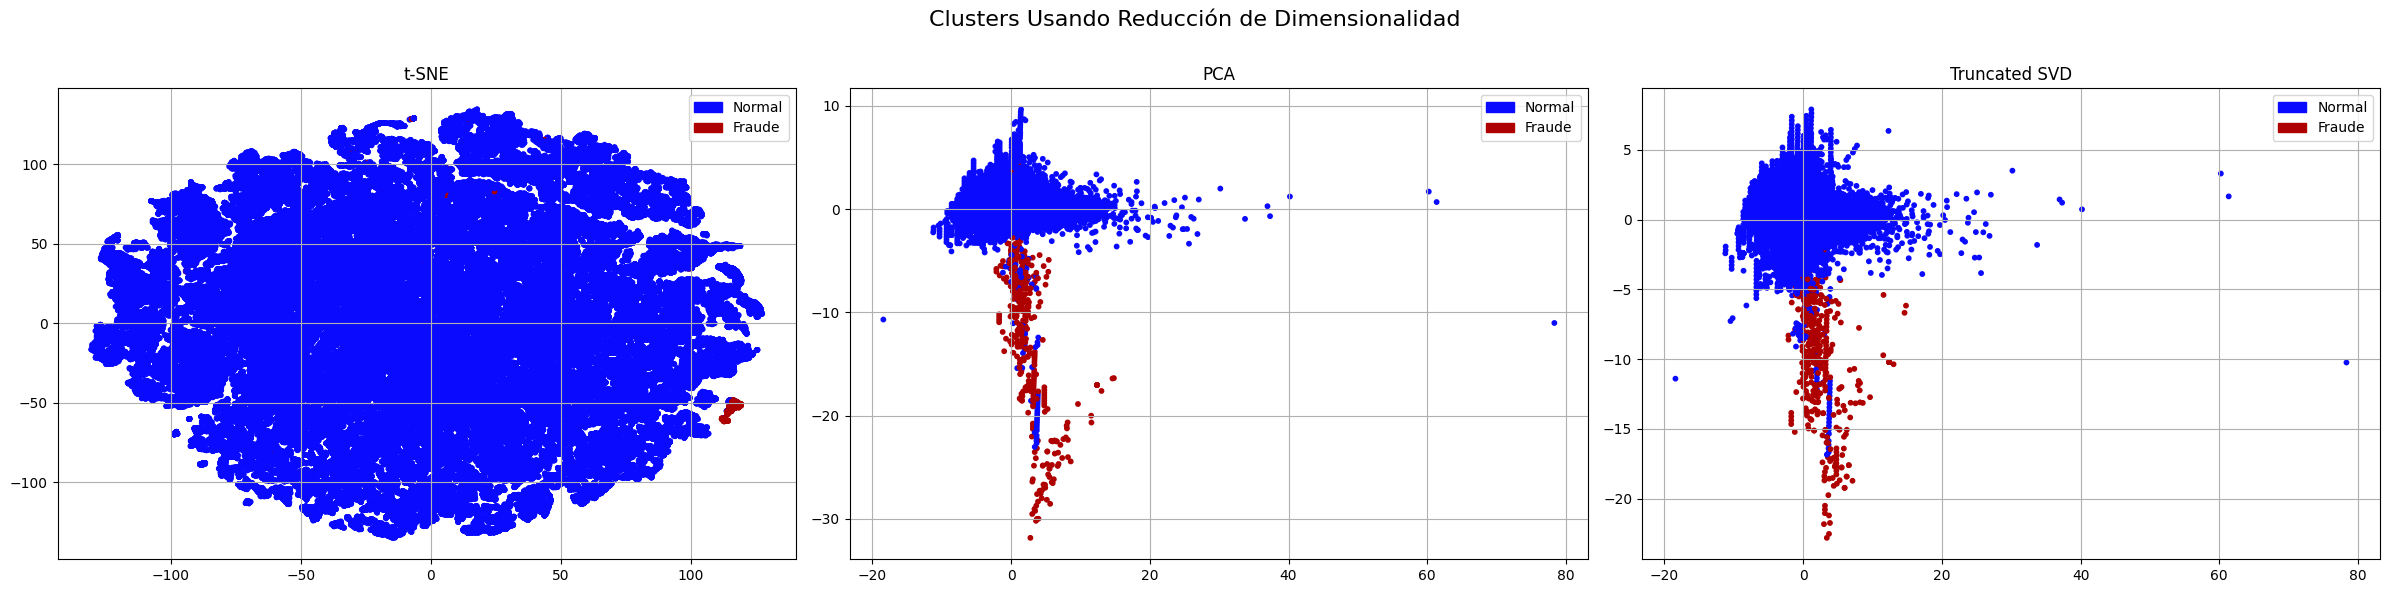

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(24, 6))
f.suptitle('Clusters Usando Reducción de Dimensionalidad', fontsize=16)

# Crear leyenda personalizada
blue_patch = mpatches.Patch(color='#0A0AFF', label='Normal')
red_patch = mpatches.Patch(color='#AF0000', label='Fraude')

# Colores según clase
colors = ['#0A0AFF' if label == 0 else '#AF0000' for label in y]

# t-SNE
ax1.scatter(X_reduced_tsne[:,0], X_reduced_tsne[:,1], c=colors, s=10)
ax1.set_title('t-SNE')
ax1.grid(True)
ax1.legend(handles=[blue_patch, red_patch])

# PCA
ax2.scatter(X_reduced_pca[:,0], X_reduced_pca[:,1], c=colors, s=10)
ax2.set_title('PCA')
ax2.grid(True)
ax2.legend(handles=[blue_patch, red_patch])

# SVD
ax3.scatter(X_reduced_svd[:,0], X_reduced_svd[:,1], c=colors, s=10)
ax3.set_title('Truncated SVD')
ax3.grid(True)
ax3.legend(handles=[blue_patch, red_patch])

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

In [8]:
f.savefig("../outputs/cluster_reduction_plot.png", dpi=300)